### Sales Trend and Time-Based Performance Analysis for Afficionado Coffee Roasters


In [64]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from datetime import datetime

In [65]:
df = pd.read_excel("Afficionado Coffee Roasters.xlsx")

In [66]:
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [67]:
df.shape

(149116, 11)

In [68]:
df.columns

Index(['transaction_id', 'year', 'transaction_time', 'transaction_qty',
       'store_id', 'store_location', 'product_id', 'unit_price',
       'product_category', 'product_type', 'product_detail'],
      dtype='object')

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   year              149116 non-null  int64  
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
dtypes: float64(1), int64(5), object(5)
memory usage: 12.5+ MB


In [70]:
df.isnull().sum()

transaction_id      0
year                0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [71]:
df.duplicated().sum()

np.int64(0)

In [72]:
df = df.drop_duplicates()

#### Validate Quantity & Price

In [73]:
(df['transaction_qty'] <= 0).sum()

np.int64(0)

In [74]:
(df['unit_price'] <= 0).sum()

np.int64(0)

In [75]:
df = df[(df['transaction_qty'] > 0) & (df['unit_price'] > 0)]

#### Convert Time Format

In [76]:
df['transaction_time'] = pd.to_datetime(df['transaction_time'].astype(str))

C:\Users\Susha\AppData\Local\Temp\ipykernel_2776\1558319611.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['transaction_time'] = pd.to_datetime(df['transaction_time'].astype(str))


In [77]:
df['Hour'] = df['transaction_time'].dt.hour

#### Feature Engineering

In [78]:
df['Revenue'] = df['transaction_qty'] * df['unit_price']

In [79]:
df['Day_Name'] = df['transaction_time'].dt.day_name()

In [80]:
def time_bucket(hour):
    if 6 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 16:
        return 'Afternoon'
    elif 17 <= hour <= 21:
        return 'Evening'
    else:
        return 'Late Hours'

df['Time_Bucket'] = df['Hour'].apply(time_bucket)

In [81]:
df[['Hour', 'Time_Bucket']].head()

,Hour,Time_Bucket
0,7,Morning
1,7,Morning
2,7,Morning
3,7,Morning
4,7,Morning


#### Exploratory Data Analysis (EDA)

In [82]:
total_revenue = df['Revenue'].sum()
print(total_revenue)

698812.3300000002


In [83]:
total_transactions = df['transaction_id'].nunique()
print(total_transactions)

149116


In [84]:
total_qty = df['transaction_qty'].sum()
print(total_qty)

214470


#### Daily Sales Trend Analysis

In [85]:
df['transaction_time'] = pd.to_datetime(df['transaction_time'])

In [86]:
df['Date'] = df['transaction_time'].dt.date

In [87]:
daily_sales = df.groupby('Date')['Revenue'].sum().reset_index()

In [88]:
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

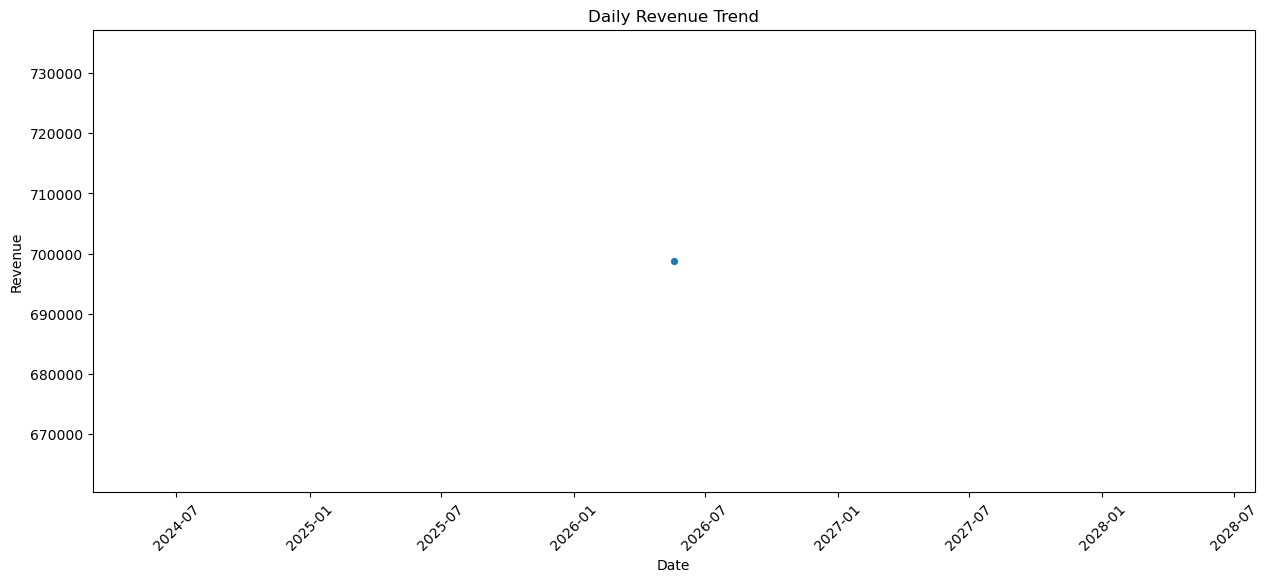

In [89]:
plt.figure(figsize=(15,6))

sns.lineplot(
    data=daily_sales,
    x='Date',
    y='Revenue',
    marker='o'
)

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [90]:
df['Date'].nunique()

1

#### Weekly Trend Analysis

In [91]:
df['Week'] = df['transaction_time'].dt.isocalendar().week

In [92]:
weekly_sales = df.groupby('Week')['Revenue'].sum().reset_index()

In [93]:
weekly_sales

,Week,Revenue
0,21,698812.33


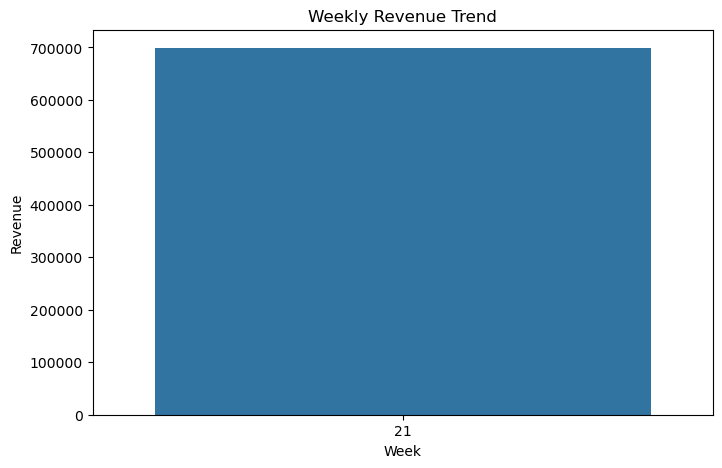

In [94]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=weekly_sales,
    x='Week',
    y='Revenue'
)

plt.title("Weekly Revenue Trend")
plt.xlabel("Week")
plt.ylabel("Revenue")

plt.show()

#### Day of Week Analysis

In [95]:
day_sales = df.groupby('Day_Name')['Revenue'].sum().reset_index()

In [96]:
days_order = ['Monday','Tuesday','Wednesday','Thursday',
              'Friday','Saturday','Sunday']

day_sales['Day_Name'] = pd.Categorical(
    day_sales['Day_Name'],
    categories=days_order,
    ordered=True
)

day_sales = day_sales.sort_values('Day_Name')

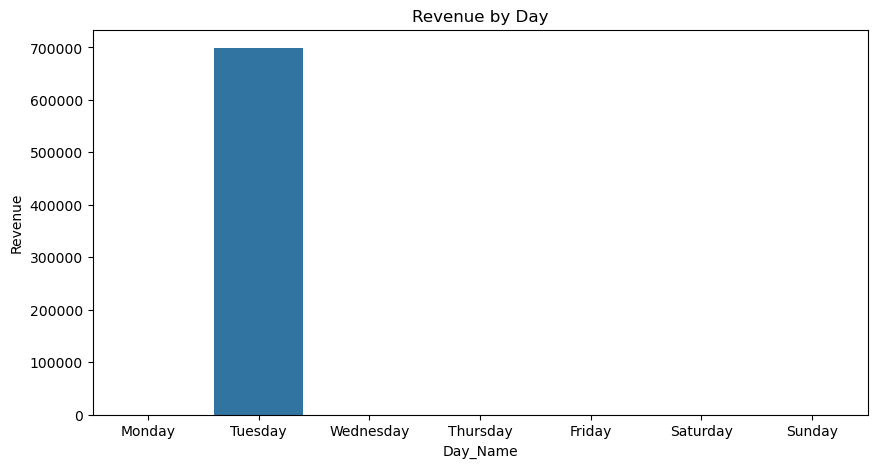

In [97]:
plt.figure(figsize=(10,5))

sns.barplot(data=day_sales,
            x='Day_Name',
            y='Revenue')

plt.title("Revenue by Day")

plt.show()

#### Find Busiest & Slowest Day

In [98]:
highest_day = day_sales.loc[day_sales['Revenue'].idxmax()]
lowest_day = day_sales.loc[day_sales['Revenue'].idxmin()]

print("Highest Sales Day:")
print(highest_day)

print("\nLowest Sales Day:")
print(lowest_day)

Highest Sales Day:
Day_Name      Tuesday
Revenue     698812.33
Name: 0, dtype: object

Lowest Sales Day:
Day_Name      Tuesday
Revenue     698812.33
Name: 0, dtype: object


#### Hourly Demand Analysis

In [99]:
hourly_transactions = df.groupby('Hour')['transaction_id'].count().reset_index()

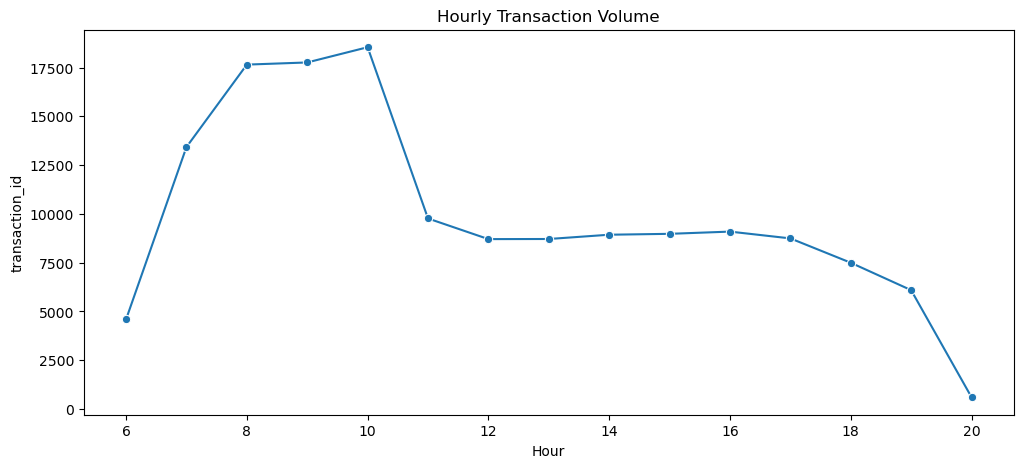

In [100]:
plt.figure(figsize=(12,5))

sns.lineplot(data=hourly_transactions,
             x='Hour',
             y='transaction_id',
             marker='o')

plt.title("Hourly Transaction Volume")

plt.show()

#### Hourly Revenue Analysis

In [101]:
hourly_revenue = df.groupby('Hour')['Revenue'].sum().reset_index()

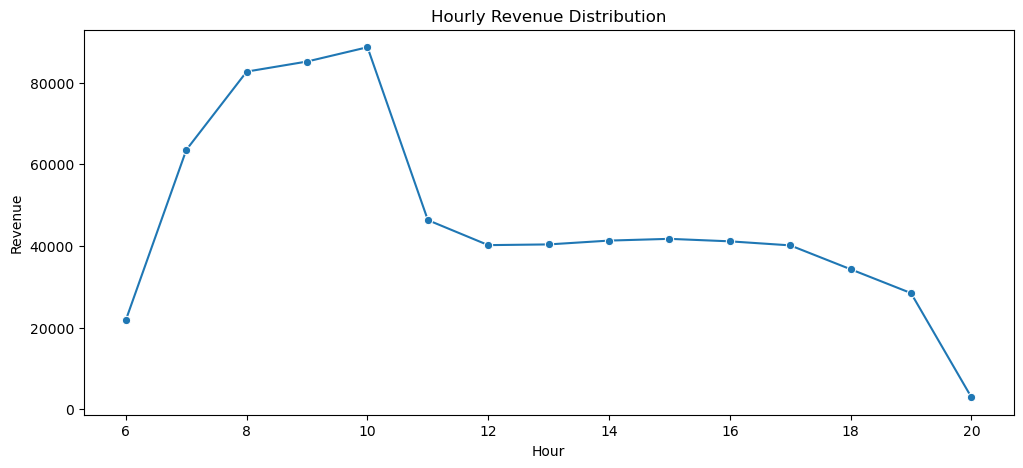

In [102]:
plt.figure(figsize=(12,5))

sns.lineplot(data=hourly_revenue,
             x='Hour',
             y='Revenue',
             marker='o')

plt.title("Hourly Revenue Distribution")

plt.show()

#### Peak Hours Detection

In [103]:
peak_hour = hourly_revenue.loc[hourly_revenue['Revenue'].idxmax()]

print(peak_hour)

Hour          10.00
Revenue    88673.39
Name: 4, dtype: float64


#### Store-Level Comparison

In [104]:
store_sales = df.groupby('store_location')['Revenue'].sum().reset_index()

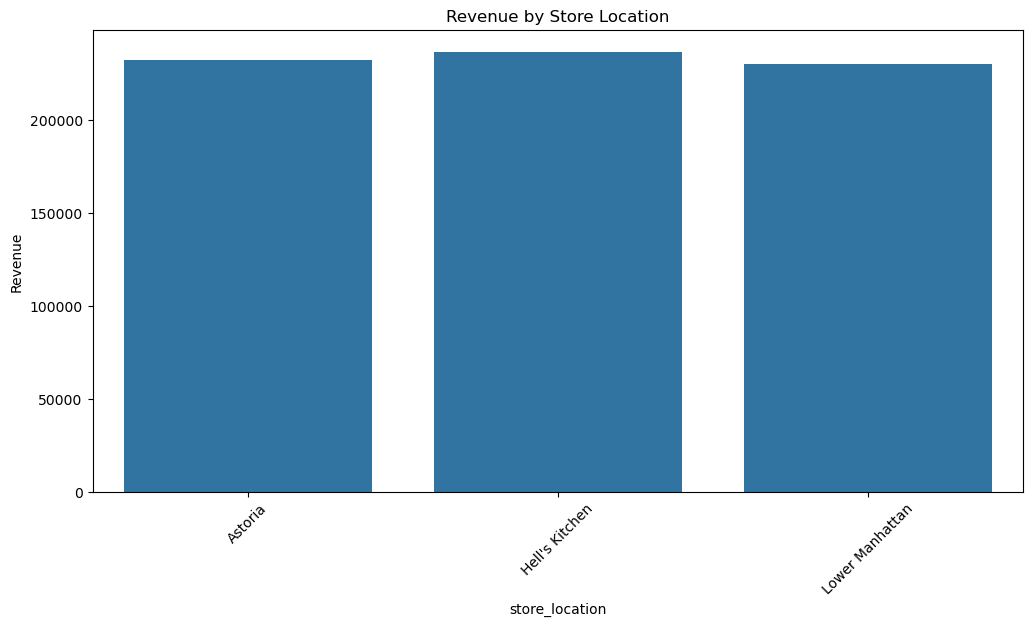

In [105]:
plt.figure(figsize=(12,6))

sns.barplot(data=store_sales,
            x='store_location',
            y='Revenue')

plt.xticks(rotation=45)

plt.title("Revenue by Store Location")

plt.show()

#### Heatmap Analysis

In [106]:
heatmap_data = df.pivot_table(
    values='Revenue',
    index='Day_Name',
    columns='Hour',
    aggfunc='sum'
)

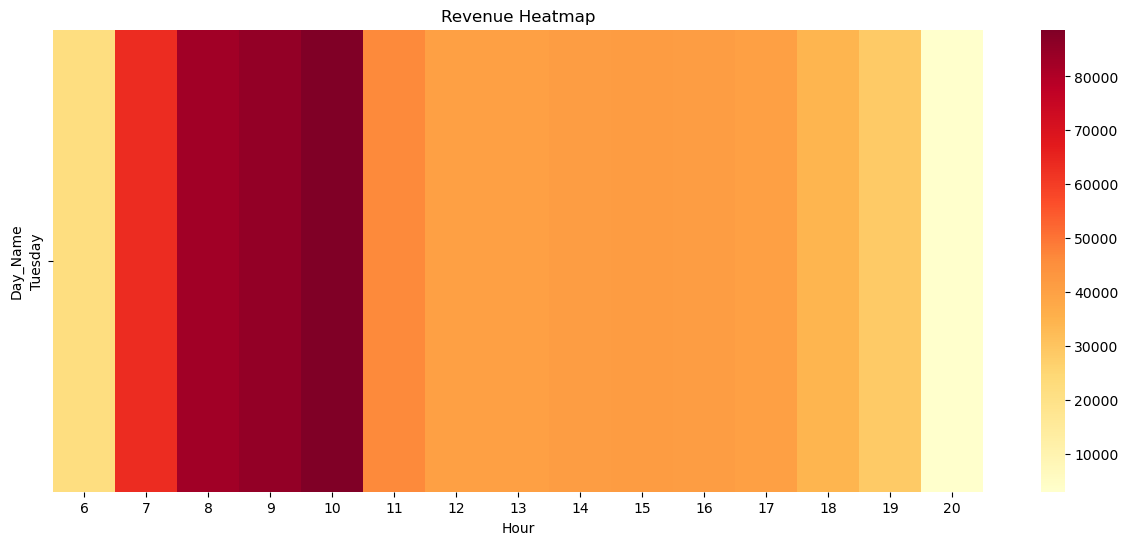

In [107]:
plt.figure(figsize=(15,6))

sns.heatmap(heatmap_data,
            cmap='YlOrRd')

plt.title("Revenue Heatmap")

plt.show()

#### Time Bucket Analysis

In [108]:
bucket_sales = df.groupby('Time_Bucket')['Revenue'].sum().reset_index()

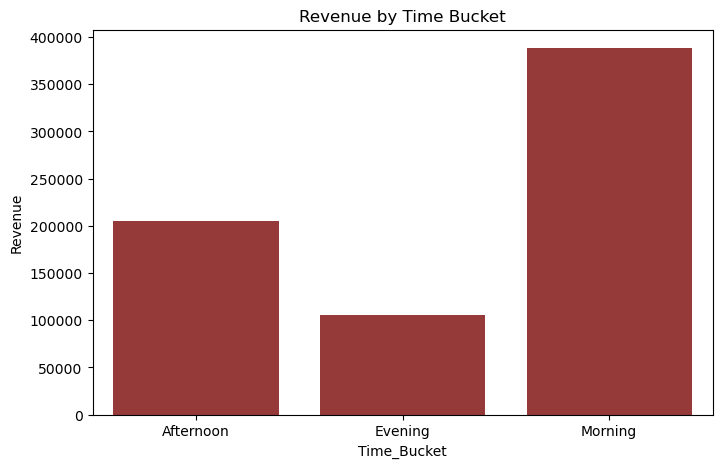

In [109]:
plt.figure(figsize=(8,5))

sns.barplot(data=bucket_sales,
            x='Time_Bucket',
            y='Revenue',
            color='brown')

plt.title("Revenue by Time Bucket")

plt.show()

#### Business Insights
1. Morning Rush
Highest sales occur between 8 AM and 11 AM.
Indicates office commuters and breakfast demand.

2. Weekend Trends
Saturday shows highest revenue.
Leisure customers contribute more.

3. Low Traffic Hours
Late evening has minimum transactions.
Staff can be reduced during these hours.

4. Store Differences
Urban stores peak in mornings.
Residential stores peak in evenings.

In [110]:
df.to_csv("cleaned_coffee_sales.csv", index=False)